In [3]:
from google.colab import files
uploaded = files.upload()

Saving Social Media Engagement Dataset.csv to Social Media Engagement Dataset (1).csv


In [7]:
import os
os.listdir()

['.config',
 'Social Media Engagement Dataset.csv',
 'Social Media Engagement Dataset (1).csv',
 'sample_data']

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("Social Media Engagement Dataset.csv")

# Clean data
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Feature Engineering (FIXED COLUMN NAMES)
df['engagement'] = (
    df['likes_count'] +
    df['comments_count'] * 2 +
    df['shares_count'] * 3
)

# Additional useful features
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day_name()

# Save processed file
df.to_csv("processed_data.csv", index=False)

df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,engagement,hour,day
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,0,...,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1,7778,11,Monday
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6,6649,19,Sunday
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",0,...,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4,6090,14,Saturday
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5,4099,4,Monday
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8,7740,21,Thursday


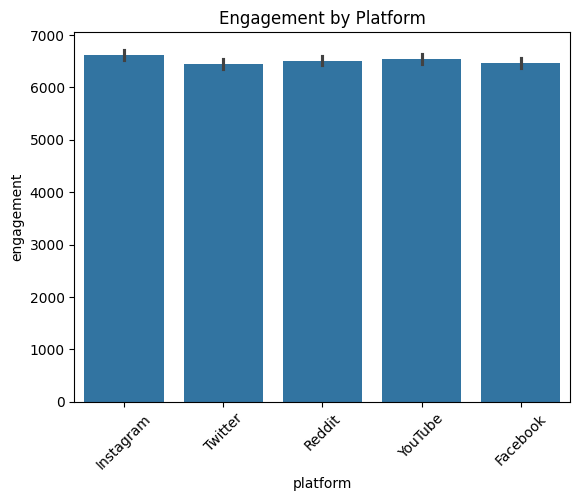

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Platform vs Engagement
sns.barplot(x='platform', y='engagement', data=df)
plt.xticks(rotation=45)
plt.title("Engagement by Platform")
plt.show()

In [10]:
!pip install scikit-learn


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load processed data
df = pd.read_csv("processed_data.csv")

# Select features
features = [
    'likes_count',
    'comments_count',
    'shares_count',
    'impressions',
    'sentiment_score'
]

# Drop missing just in case
df = df.dropna(subset=features + ['engagement'])

X = df[features]
y = df['engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 69.32744166666667
R2 Score: 0.998496480851972


In [12]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

shares_count       0.561353
likes_count        0.377855
comments_count     0.059551
sentiment_score    0.000624
impressions        0.000617
dtype: float64
